# Praktikum 07 | ML Senin Pagi

Nama : Rika Rahma

NIM : 011022214

Rombel : TI08 - 2022

# 1. Import Library

In [2]:
# Library digunakan untuk analisis data, visualisasi, preprocessing, dan evaluasi model.
import pandas as pd               # untuk manipulasi data
import numpy as np                # untuk perhitungan numerik
import matplotlib.pyplot as plt   # untuk visualisasi hasil
import seaborn as sns             # untuk visualisasi tambahan (opsional)
from sklearn.model_selection import train_test_split   # untuk membagi data latih & uji
from sklearn.preprocessing import StandardScaler       # untuk standarisasi fitur numerik
from sklearn.metrics import r2_score, mean_squared_error  # untuk evaluasi model
import statsmodels.api as sm      # untuk membangun model OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor  # untuk cek multikolinearitas

# 2. Load Dataset

In [3]:
# Menghubungkan colab dengan Google Drive
from google.colab import drive
drive.mount ('/content/gdrive')

Mounted at /content/gdrive


In [4]:
# Memanggil dataset lewat Gdrive
path = '/content/gdrive/MyDrive/Praktikum_ML/praktikum07/data/'

In [5]:
# Membaca file CSV menggunakan pandas
df = pd.read_csv(path + 'dataset_satelit.csv')
df.head()

,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541


In [6]:
# Cek informasi kolom dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   No         594 non-null    int64  
 1   Longitude  594 non-null    float64
 2   Lattitude  594 non-null    float64
 3   N          594 non-null    float64
 4   P          594 non-null    float64
 5   K          593 non-null    float64
 6   Ca         594 non-null    float64
 7   Mg         594 non-null    object 
 8   Fe         594 non-null    float64
 9   Mn         594 non-null    float64
 10  Cu         594 non-null    float64
 11  Zn         594 non-null    float64
 12  B          594 non-null    float64
 13  b12        594 non-null    float64
 14  b11        594 non-null    float64
 15  b9         594 non-null    float64
 16  b8a        594 non-null    float64
 17  b8         594 non-null    float64
 18  b7         594 non-null    float64
 19  b6         594 non-null    float64
 20  b5        

In [7]:
df.describe()

,No,Longitude,Lattitude,N,P,K,Ca,Fe,Mn,Cu,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
count,594.000000,594.000000,594.000000,594.000000,594.000000,593.000000,594.000000,594.000000,594.000000,594.000000,...,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000
mean,297.500000,106.878644,-1.024933,2.259091,0.141380,0.582175,0.595094,74.613771,308.034697,2.391195,...,0.177291,0.234474,0.102789,28.640422,28.664891,28.609569,0.202587,0.051524,0.269642,0.062320
std,171.617307,4.949840,0.965349,0.395499,0.019782,0.222567,0.366118,55.579655,241.731643,1.580296,...,0.155615,0.070516,0.112310,15.325347,15.380384,15.329170,0.104357,0.012959,0.143728,0.024218
min,1.000000,102.760857,-2.333750,1.140000,0.090000,0.122000,0.050000,21.080000,3.160000,0.090000,...,0.014100,0.115170,0.021460,0.127000,0.098600,0.026000,0.008700,0.016900,0.009300,0.016300
25%,149.250000,102.927811,-2.233338,1.982500,0.130000,0.429000,0.320000,40.705000,124.015000,1.172500,...,0.046925,0.183210,0.039535,31.959745,31.968948,33.685353,0.183085,0.040250,0.244935,0.052772
50%,297.500000,103.581969,-0.602276,2.280000,0.140000,0.549000,0.540000,65.650000,239.445000,2.225000,...,0.072700,0.213385,0.046550,35.067930,35.110415,34.611565,0.233590,0.050415,0.310380,0.068380
75%,445.750000,113.403797,-0.257349,2.570000,0.150000,0.710000,0.790000,87.372500,434.990000,3.357500,...,0.318900,0.262242,0.059190,38.319135,38.441065,39.002760,0.271790,0.060410,0.364505,0.079020
max,594.000000,113.434700,0.069251,3.230000,0.220000,1.489000,2.820000,559.100000,2009.320000,8.170000,...,0.751400,0.512210,0.373000,47.592900,48.014640,39.209330,0.658960,0.122300,0.814170,0.150620


In [22]:
print(df.columns)

Index(['No', 'Longitude', 'Lattitude', 'N', 'P', 'K', 'Ca', 'Mg', 'Fe', 'Mn',
       'Cu', 'Zn', 'B', 'b12', 'b11', 'b9', 'b8a', 'b8', 'b7', 'b6', 'b5',
       'b4', 'b3', 'b2', 'b1', 'Sigma_VV', 'Sigma_VH', 'plia', 'lia', 'iafe',
       'gamma0_vv', 'gamma0_vh', 'beta0_vv', 'beta0_vh', 'NDVI', 'SWIR_ratio',
       'K_proxy'],
      dtype='object')


# 3. Tentukan Target dan Fitur

In [9]:
# Fitur: gabungan data geospasial, optik (b1–b12), radar (Sigma, Gamma, Beta),
# serta atribut tambahan (plia, lia, iafe)
target = 'K'
feature_cols = [
    'Longitude', 'Lattitude',
    'b1','b2','b3','b4','b5','b6','b7','b8','b8a','b9','b11','b12',
    'Sigma_VV','Sigma_VH','gamma0_vv','gamma0_vh','beta0_vv','beta0_vh',
    'plia','lia','iafe'
]

print(f"Target (y): 'K', Fitur (X): {len(feature_cols)} kolom Radar.")

Target (y): 'K', Fitur (X): 23 kolom Radar.


# 4. Feature Engineering

In [10]:
# Membuat fitur turunan yang memiliki hubungan potensial dengan unsur Kalium.
# NDVI: indeks vegetasi dari band NIR (b8) dan merah (b4)
# SWIR_ratio: rasio band SWIR (b11 / b12) untuk mendeteksi kelembapan
# K_proxy: interaksi antara SWIR dan radar VV sebagai proksi Kalium
df['NDVI'] = (df['b8'] - df['b4']) / (df['b8'] + df['b4'] + 1e-8)
df['SWIR_ratio'] = df['b11'] / (df['b12'] + 1e-8)
df['K_proxy'] = df['b11'] * df['Sigma_VV']


# Tambahkan fitur hasil rekayasa ke daftar fitur utama
feature_cols += ['NDVI', 'SWIR_ratio', 'K_proxy']

# 5. Pembersihan Data

In [11]:
# Menghapus baris yang memiliki nilai kosong (NaN) pada kolom fitur atau target.
df_clean = df.dropna(subset=[target] + feature_cols)

# Pisahkan data menjadi fitur (X) dan target (y)
X = df_clean[feature_cols]
y = df_clean[target]

# 6. Pembagian Data Latih dan Uji

In [12]:
# Data dibagi dengan rasio 80:20 (80% pelatihan, 20% pengujian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Normalisasi / Standarisasi

In [13]:
# Standarisasi diperlukan agar semua fitur memiliki skala yang sebanding.
# Ini penting karena model OLS sensitif terhadap perbedaan skala antar variabel.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. Tambahkan Konstanta (Intercept)

In [14]:
# Model OLS memerlukan kolom konstanta agar dapat menghitung intercept (β0).
X_train_ols = sm.add_constant(X_train_scaled)
X_test_ols = sm.add_constant(X_test_scaled)

# 9. Konversi ke DataFrame untuk interpretasi

In [15]:
# Digunakan agar kolom fitur tetap terbaca dengan jelas dalam output OLS.
cols = ['const'] + feature_cols
X_train_ols_df = pd.DataFrame(X_train_ols, columns=cols)
X_test_ols_df = pd.DataFrame(X_test_ols, columns=cols)

# 10. Pembangunan Model OLS Regression

In [16]:
# Model di-fit menggunakan data latih.
# statsmodels menghasilkan ringkasan lengkap (koefisien, p-value, R², dll.)
model_ols = sm.OLS(y_train.reset_index(drop=True), X_train_ols_df).fit()

# Tampilkan hasil ringkasan model
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      K   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     13.08
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.56e-40
Time:                        10:33:12   Log-Likelihood:                 168.66
No. Observations:                 474   AIC:                            -283.3
Df Residuals:                     447   BIC:                            -171.0
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5838      0.008     72.804      0.0

#  11. Prediksi Data Uji

In [17]:
# Memprediksi data uji
y_pred = model_ols.predict(X_test_ols_df)

# 12. Evaluasi Model

In [18]:
# R² (R-squared): proporsi variasi data yang dapat dijelaskan oleh model.
# RMSE: akar dari MSE, menunjukkan seberapa jauh prediksi menyimpang dari nilai aktual.
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR²: {r2:.4f}, RMSE: {rmse:.4f}")


R²: 0.3318, RMSE: 0.1731


# 13. Analisis Multikolinearitas (VIF)

In [19]:
# VIF (Variance Inflation Factor) digunakan untuk mengukur korelasi antar fitur.
# Nilai VIF > 10 menunjukkan adanya multikolinearitas tinggi yang sebaiknya dihapus.
vif_data = pd.DataFrame()
vif_data["feature"] = feature_cols
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled, i) for i in range(X_train_scaled.shape[1])]
print("\nVIF (idealnya < 5):")
print(vif_data.sort_values("VIF", ascending=False))


VIF (idealnya < 5):
       feature           VIF
10         b8a  32100.872128
11          b9  31775.386318
21         lia  18426.177594
20        plia  18250.161936
9           b8   9307.004495
22        iafe   8627.284403
18    beta0_vv    801.971434
16   gamma0_vv    778.415791
0    Longitude    689.338196
4           b3    632.935849
1    Lattitude    336.041067
5           b4    264.744281
3           b2    232.289753
24  SWIR_ratio    194.792953
15    Sigma_VH    157.282684
12         b11    117.858418
19    beta0_vh    105.883752
7           b6     84.125365
23        NDVI     83.776089
14    Sigma_VV     76.785210
25     K_proxy     72.517385
8           b7     55.113960
13         b12     54.164624
6           b5     52.284286
17   gamma0_vh     50.927117
2           b1     43.907918


# 14. Visualisasi Hasil Prediksi

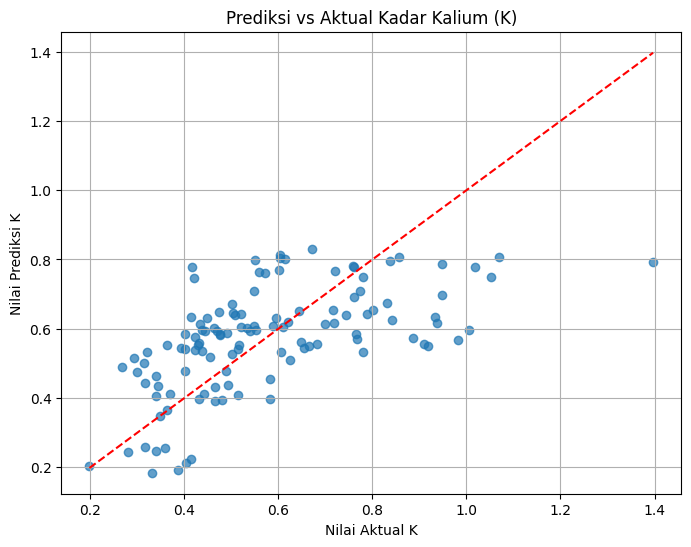

In [20]:
# Membandingkan nilai aktual vs prediksi untuk melihat akurasi model secara visual.
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Nilai Aktual K")
plt.ylabel("Nilai Prediksi K")
plt.title("Prediksi vs Aktual Kadar Kalium (K)")
plt.grid(True)
plt.show()

# 15. Kesimpulan

In [21]:
# Model OLS berhasil dibangun untuk memprediksi kadar Kalium (K)
# berdasarkan kombinasi fitur citra satelit (optik, radar, dan hasil rekayasa fitur).
# Nilai R² menunjukkan seberapa besar variasi K yang dapat dijelaskan oleh model,
# sedangkan RMSE menunjukkan tingkat error prediksi.
# Fitur dengan VIF tinggi sebaiknya dievaluasi kembali untuk menghindari multikolinearitas.
# Secara umum, model ini dapat dijadikan dasar analisis hubungan antara citra satelit
# dan kandungan unsur hara tanah, khususnya Kalium.